## Q9 — Which player has won the most tournaments in a single month?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
IN_DIR = "cleaned_data"

rnd = pd.read_parquet(f'{IN_DIR}/round.parquet')
tourn = pd.read_parquet(f'{IN_DIR}/tournament.parquet')
event = pd.read_parquet(f'{IN_DIR}/event.parquet')
home = pd.read_parquet(f'{IN_DIR}/home_team.parquet')
away = pd.read_parquet(f'{IN_DIR}/away_team.parquet')

In [3]:
# round coverage: main draw vs qualifying
tournament = tourn.copy()
tournament['is_quali'] = (
    tournament['tournament_name']
    .astype(str)
    .str.contains('qualif', case=False, na=False)
)

main_ids = set(tournament.loc[~tournament['is_quali'], 'match_id'])
quali_ids = set(tournament.loc[tournament['is_quali'], 'match_id'])
round_ids = set(rnd['match_id'])   # round.parquet

main_cov = 100 * len(main_ids & round_ids) / len(main_ids)
quali_cov = 100 * len(quali_ids & round_ids) / len(quali_ids)

print(f"main-draw round coverage: {main_cov:.1f}%")
print(f"qualifying round coverage: {quali_cov:.1f}%")


final_ids = set(rnd.loc[rnd['is_final'] == True, 'match_id'])
print("any final in qualifying?", bool(final_ids & quali_ids))
print("all finals in main draw?", final_ids.issubset(main_ids))

main-draw round coverage: 92.1%
qualifying round coverage: 13.3%
any final in qualifying? False
all finals in main draw? True


In [4]:
# "Tournament" here needs care: tournament_name includes qualifying-stage
# events alongside real main-draw tournaments. 
# Winning a qualifying final means "qualified for the draw", not "won a title" --
# including those would badly distort the answer. Restrict to main draw.
# This also happens to solve most of the round-data coverage problem: main
# draw matches have 92% round coverage vs 13% for qualifying, and every
# single is_final=True match in the dataset is in the main draw anyway.

tourn['is_quali'] = tourn['tournament_name'].str.contains('Quali', case=False, na=False)
main_draw = tourn[~tourn['is_quali']]
 
finals = (rnd[rnd['is_final'] == True][['match_id']]
          .merge(main_draw[['match_id', 'tournament_name', 'tournament_category_name']], on='match_id'))
print(f"{len(finals)} main-draw final matches identified.")

ev = event[event['score_ready']==True].copy()
finals = finals.merge(ev[['match_id', 'winner_code', 'match_completed', 'start_month']],
                       on='match_id', how='left')
n_no_result = int((finals['match_completed'] != True).sum())
finals = finals[finals['match_completed'] == True]
print(f"{n_no_result} finals have no recorded winner (excluded, not guessed).")

260 main-draw final matches identified.
28 finals have no recorded winner (excluded, not guessed).


In [5]:
# Attribute the winning player -- identical logic to Q3
home_w = finals[finals['winner_code'] == 1].merge(
    home[['match_id', 'player_id', 'full_name']], on='match_id', how='left')
away_w = finals[finals['winner_code'] == 2].merge(
    away[['match_id', 'player_id', 'full_name']], on='match_id', how='left')
wins = pd.concat([home_w, away_w], ignore_index=True)
 
n_unattributed = int(wins['player_id'].isna().sum())
wins = wins.dropna(subset=['player_id'])
print(f"{n_unattributed} title wins have no player row available (excluded).")
print(f"{len(wins)} tournament titles remain, attributable to a specific player in a specific month.\n")

5 title wins have no player row available (excluded).
227 tournament titles remain, attributable to a specific player in a specific month.



In [6]:
# Count titles per player per month
by_month = (wins.groupby(['player_id', 'full_name', 'start_month'])
            .size().reset_index(name='titles')
            .sort_values('titles', ascending=False))
 
top = by_month.iloc[0]
max_titles = int(by_month['titles'].max())
n_tied = int((by_month['titles'] == max_titles).sum())
print(f"Most tournaments won in a single month: {max_titles}, achieved by {n_tied} player(s):")
print(by_month[by_month['titles'] == max_titles].to_string(index=False))
print()
print(by_month.head(10).to_string(index=False))

Most tournaments won in a single month: 3, achieved by 4 player(s):
 player_id             full_name start_month  titles
  230049.0 Jianu, Filip Cristian     2024-03       3
   50901.0         Popko, Dmitry     2024-02       3
  202572.0         Gengel, Marek     2024-02       3
  372311.0          Nicod, Jakub     2024-03       3

 player_id                         full_name start_month  titles
  230049.0             Jianu, Filip Cristian     2024-03       3
   50901.0                     Popko, Dmitry     2024-02       3
  202572.0                     Gengel, Marek     2024-02       3
  372311.0                      Nicod, Jakub     2024-03       3
   82133.0 Dellien Velasco, Murkel Alejandro     2024-02       2
  231620.0                  Chidekh, Clement     2024-02       2
  341818.0                      Faria, Jaime     2024-03       2
  349351.0             Ciric Bagaric, Lucija     2024-02       2
   63642.0             Kwiatkowski, Thai-Son     2024-03       2
  152766.0      

In [7]:
# list which tournaments, for each tied top player, as a sanity check
for _, row in by_month[by_month['titles'] == max_titles].iterrows():
    detail = wins[(wins.player_id == row['player_id']) & (wins.start_month == row['start_month'])]
    print(f"\nTournaments won by {row['full_name']} in {row['start_month']}:")
    print(detail[['tournament_name', 'tournament_category_name']].to_string(index=False))


Tournaments won by Jianu, Filip Cristian in 2024-03:
                         tournament_name tournament_category_name
Kish Island, Singles Main, M-ITF-IRI-03A                  ITF Men
Kish Island, Singles Main, M-ITF-IRI-04A                  ITF Men
    Antalya, Singles Main, M-ITF-TUR-11A                  ITF Men

Tournaments won by Popko, Dmitry in 2024-02:
                        tournament_name tournament_category_name
   Sunrise, Singles Main, M-ITF-USA-03A                  ITF Men
Palm Coast, Singles Main, M-ITF-USA-04A                  ITF Men
    Naples, Singles Main, M-ITF-USA-05A                  ITF Men

Tournaments won by Gengel, Marek in 2024-02:
                            tournament_name tournament_category_name
Sharm ElSheikh, Singles Main, M-ITF-EGY-01A                  ITF Men
Sharm ElSheikh, Singles Main, M-ITF-EGY-02A                  ITF Men
Sharm ElSheikh, Singles Main, M-ITF-EGY-03A                  ITF Men

Tournaments won by Nicod, Jakub in 2024-03:
         

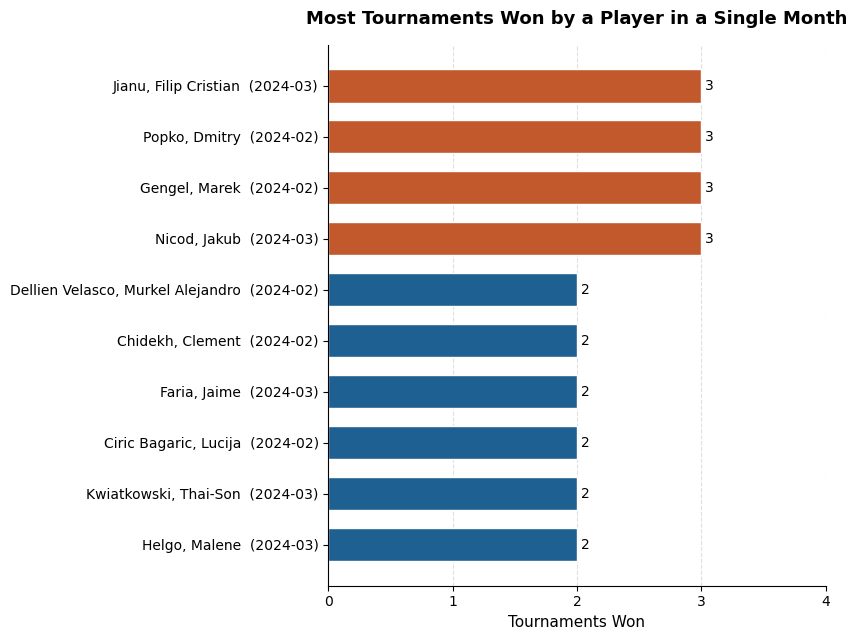

In [8]:
# Visualization
top_n = by_month[by_month['titles']>=2].iloc[::-1].tail(10)
top_n['label'] = top_n['full_name'] + '  (' + top_n['start_month'] + ')'
 
fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = ['#C1592C' if v == max_titles else '#1E6091' for v in top_n['titles']]
bars = ax.barh(top_n['label'], top_n['titles'], color=colors, edgecolor='white', height=0.65)
for bar, v in zip(bars, top_n['titles']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2, f'{int(v)}', va='center', fontsize=10)
 
ax.set_xlabel('Tournaments Won', fontsize=11)
ax.set_title('Most Tournaments Won by a Player in a Single Month', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_xticks(range(0, int(top_n['titles'].max())+2))
plt.tight_layout()
plt.savefig('charts\q9_titles_per_month.png', dpi=200, bbox_inches='tight')

Observation: Maximum is 3 tournaments in one month, reached by four players (Popko, Gengel, Jianu, Nicod) in Feb–Mar 2024, all ITF Men. Of 260 main-draw finals, 28 had no recorded winner and were excluded.

Interpretation: Three events in one month fits weekly ITF calendars; ATP-level spacing makes the same pattern less likely.

Limitation: Measured only over the months present in the data, not a full multi-year season.